# Aula Prática 1 - Computação Quântica (versão didática para Colab)

Este notebook foi organizado para aula de laboratório com progressão em passos curtos, verificações rápidas e exercícios.

## Como usar em sala

1. Rode a Célula 1 (setup).
2. Se aparecer mensagem de reinício, reinicie o runtime e rode a Célula 1 de novo.
3. Siga as seções na ordem.
4. Nos exercícios, edite apenas as partes marcadas com TODO.

In [4]:
# Célula 1 - Setup para Google Colab
import importlib.util
import subprocess
import sys

IN_COLAB = importlib.util.find_spec('google.colab') is not None

REQUIRED = {
    'qiskit': '2.4.1',
    'qiskit-aer': '0.17.2',
    'qiskit-ibm-runtime': '0.40.1',
    'pylatexenc': '2.10',
}

def _version(pkg_name):
    try:
        from importlib.metadata import version
        return version(pkg_name)
    except Exception:
        return None

if IN_COLAB:
    to_install = []
    for pkg, ver in REQUIRED.items():
        cur = _version(pkg)
        if cur != ver:
            to_install.append(f'{pkg}=={ver}')

    if to_install:
        print('Instalando dependências da aula no Colab...')
        subprocess.check_call([
            sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', *to_install
        ])
        raise SystemExit('Dependências atualizadas. Reinicie o runtime e rode esta célula novamente.')
    else:
        print('Dependências já estão na versão esperada.')
else:
    print('Ambiente local detectado. Pulando instalação automática de Colab.')

import qiskit
import qiskit_aer
import qiskit_ibm_runtime
import numpy as np
import matplotlib

print('Ambiente OK')
print('qiskit:', qiskit.__version__)
print('qiskit-aer:', qiskit_aer.__version__)
print('qiskit-ibm-runtime:', qiskit_ibm_runtime.__version__)
print('numpy:', np.__version__)
print('matplotlib:', matplotlib.__version__)

ModuleNotFoundError: No module named 'google'

## 1) Objetivos de aprendizagem

Ao final da aula, você deve conseguir:
- montar e visualizar circuitos simples no Qiskit;
- interpretar medição de 1 e 2 qubits;
- explicar o que muda quando há emaranhamento;
- comparar previsão teórica com histograma experimental.

In [1]:
# Imports da parte prática
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()

def run_counts(circuit, shots=1024):
    """Executa no simulador e retorna contagens."""
    result = sim.run(circuit, shots=shots).result()
    return result.get_counts()

## 2) Exemplo guiado A - um qubit

Ideia: comparar |0> puro com superposição gerada por Hadamard.

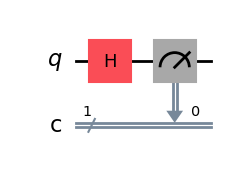

Contagens: {'0': 1019, '1': 981}


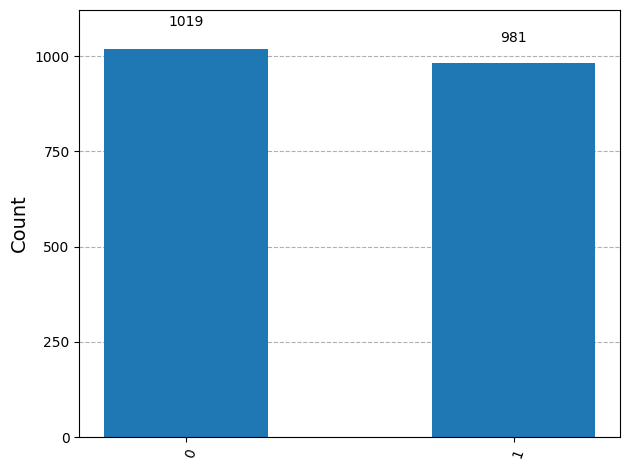

In [2]:
# Circuito 1: prepara superposição e mede
qc1 = QuantumCircuit(1, 1)
qc1.h(0)
qc1.measure(0, 0)
display(qc1.draw('mpl'))

counts1 = run_counts(qc1, shots=2000)
print('Contagens:', counts1)
display(plot_histogram(counts1))

In [3]:
# Estado vetorial correspondente (sem medição)
qc1_state = QuantumCircuit(1)
qc1_state.h(0)
psi1 = Statevector.from_instruction(qc1_state)
display(psi1.draw('latex'))

<IPython.core.display.Latex object>

## 3) Exemplo guiado B - dois qubits sem emaranhamento

Aqui aplicamos H em apenas um qubit para comparar com o próximo exemplo.

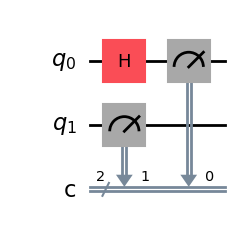

Contagens: {'00': 939, '01': 1061}


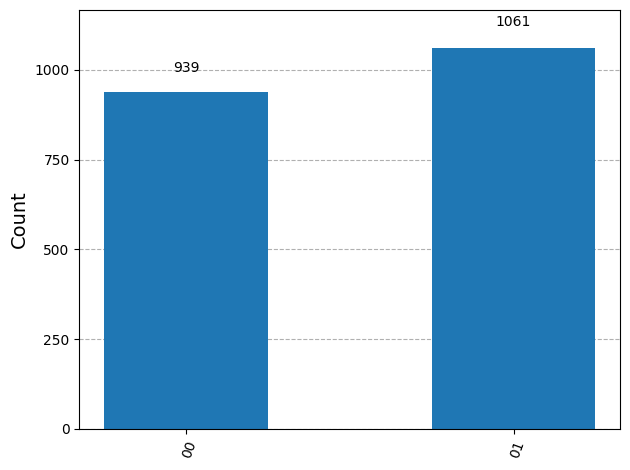

In [4]:
qc2 = QuantumCircuit(2, 2)
qc2.h(0)
qc2.measure([0, 1], [0, 1])
display(qc2.draw('mpl'))

counts2 = run_counts(qc2, shots=2000)
print('Contagens:', counts2)
display(plot_histogram(counts2))

## 4) Exemplo guiado C - estado de Bell (com emaranhamento)

Agora aplicamos H + CNOT e observamos correlação forte entre os qubits.

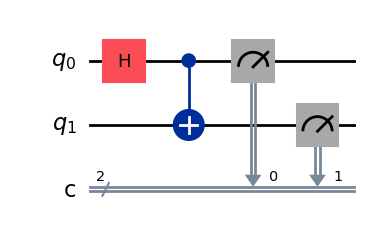

Contagens: {'11': 1999, '00': 2001}


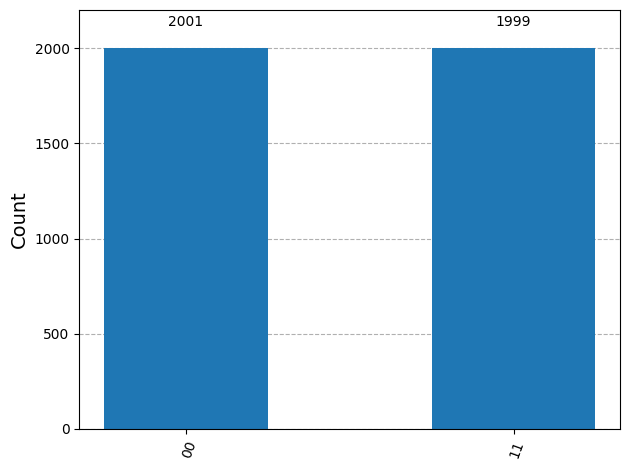

In [5]:
qc3 = QuantumCircuit(2, 2)
qc3.h(0)
qc3.cx(0, 1)
qc3.measure([0, 1], [0, 1])
display(qc3.draw('mpl'))

counts3 = run_counts(qc3, shots=4000)
print('Contagens:', counts3)
display(plot_histogram(counts3))

In [6]:
# Estado vetorial do circuito de Bell (sem medição)
qc3_state = QuantumCircuit(2)
qc3_state.h(0)
qc3_state.cx(0, 1)
psi3 = Statevector.from_instruction(qc3_state)
display(psi3.draw('latex'))

<IPython.core.display.Latex object>

## 5) Conexão com IBM Runtime (opcional)

Se a conta estiver configurada, a célula abaixo lista um backend disponível.

In [10]:
try:
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False)
    print('Backend sugerido para execução real:', backend.name)
except Exception as e:
    print('Sem credenciais/configuração de IBM Runtime nesta sessão.')
    print('Motivo:', e)

management.get:WARNING:2026-05-19 14:52:11,294: Loading default saved account


Backend sugerido para execução real: ibm_kingston


## 6) Exercícios

### Nível 1
1. Altere o número de shots nos exemplos A e C e compare a estabilidade das frequências.
2. No Exemplo B, aplique H no qubit 1 em vez do qubit 0 e interprete o histograma.

### Nível 2
3. Monte um circuito que produza o estado de Bell |Psi+> e confirme no histograma.
4. Teste o que acontece ao inserir um X antes da CNOT no qubit 1.

### Nível 3 (desafio)
5. Gere os quatro estados de Bell e escreva uma função que identifique qual estado foi produzido com base no vetor de estado.

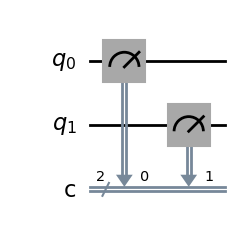

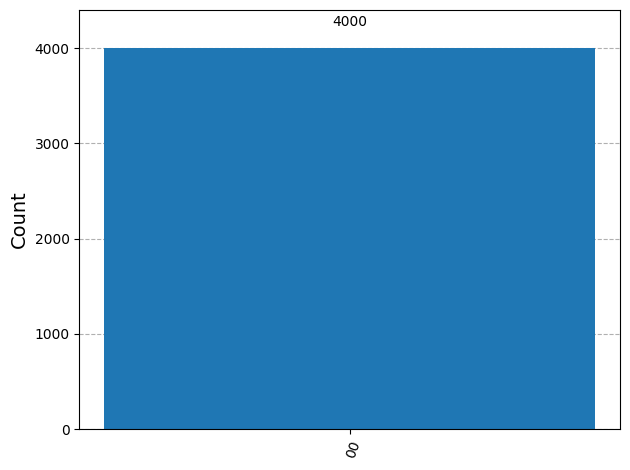

In [8]:
# Template de resposta para o exercício 3
# TODO: implemente um circuito para |Psi+>
qc_ex3 = QuantumCircuit(2, 2)

# Sua implementação aqui

qc_ex3.measure([0, 1], [0, 1])
display(qc_ex3.draw('mpl'))
counts_ex3 = run_counts(qc_ex3, shots=4000)
display(plot_histogram(counts_ex3))

In [9]:
# Template de resposta para o exercício 5
# TODO: complete a função para identificar o estado de Bell por amplitudes
def identifica_bell(psi: Statevector):
    amps = np.asarray(psi.data)
    # Dica: compare com os vetores ideais de Phi+, Phi-, Psi+, Psi-
    return 'TODO'

print('Implemente e teste com os estados gerados por você.')

Implemente e teste com os estados gerados por você.


## 7) Fechamento

Checklist rápido:
- [ ] Rodei os três exemplos guiados.
- [ ] Expliquei diferença entre superposição e emaranhamento com base no histograma.
- [ ] Resolvi ao menos 2 exercícios.
- [ ] Consegui (ou entendi como) conectar ao IBM Runtime.